In [1]:
import numpy as np
import random
from tqdm import tqdm
import seaborn as sns

In [57]:
NUM_TUBOS = 10

# m^3/s
VAZAO_ACUMULADA = [2.5/1000, 5.0/1000, 7.5/1000, 10.0/1000, 12.5/1000, 15.0/1000, 17.5/1000, 20.0/1000, 22.5/1000, 25.0/1000]

# m
COMPRIMENTO = [20, 54, 98, 120, 34, 12, 88, 122, 33, 40]

# (diâmetro - m, custo - R$/m)
CATALOGO = [(.15, 65), (.20, 98), (.25, 150), (.30, 210), (.40, 340)]
VALORES_CATALOGO = [0, 1, 2, 3, 4]

TX_CROSSOVER = .65
TX_MUTACAO = .1

NUM_POP = 50
NUM_GERACOES = 200

In [58]:
def q_max(dim:int) -> float:
    n = .013
    area = np.pi * dim**2 / 4
    r_h = dim / 4
    s = .005

    return (area * r_h**(2/3) * s**(1/2)) / n

In [59]:
def apply_penalty(dim:int, flow:float) -> bool:
    return flow > q_max(dim) * .75

In [60]:
def fitness(solution:np.array, verbose:bool = False, penalty_factor:float = 2) -> float:
    assert all([t in VALORES_CATALOGO for t in solution]), solution

    cost = 0
    penalty_cout = 0
    for i, t in enumerate(solution):
        item_cat = CATALOGO[t]
        cost_tube = item_cat[1] * COMPRIMENTO[i]
        dim_tube = item_cat[0]

        cost += cost_tube
        if apply_penalty(dim_tube, VAZAO_ACUMULADA[i]):
            cost *= penalty_factor
            penalty_cout += 1

    if verbose:
        print(f"Cost: {cost}, Penalty Count: {penalty_cout}")
    
    return cost

In [61]:
def selection(pop:np.array, fitness_pop:np.array) -> np.array:
    assert pop.shape == (NUM_POP, NUM_TUBOS)
    assert fitness_pop.shape == (NUM_POP,), f"{fitness_pop.shape} != {NUM_POP}"

    new_pop = list()
    while len(new_pop) != NUM_POP:
        idxs = np.random.randint(low=0, high=NUM_POP, size=2)
        i1, f1 = pop[idxs[0]], fitness_pop[idxs[0]]
        i2, f2 = pop[idxs[1]], fitness_pop[idxs[1]]

        if f1 <= f2:
            new_pop.append(i1)
        else:
            new_pop.append(i2)
    
    new_pop = np.array(new_pop)
    assert new_pop.shape == pop.shape
    return new_pop

In [62]:
def crossover(pop:np.array) -> np.array:
    assert pop.shape == (NUM_POP, NUM_TUBOS)

    new_pop = list()
    while len(new_pop) != NUM_POP:
        idxs_pais = np.random.randint(low=0, high=NUM_POP, size=2)
        p1 = pop[idxs_pais[0]]
        p2 = pop[idxs_pais[1]]

        if random.random() <= TX_CROSSOVER:
            half = int(NUM_TUBOS / 2)
            c1 = [p1[i] if i < half else p2[i] for i in range(NUM_TUBOS)]
            c2 = [p2[i] if i < half else p1[i] for i in range(NUM_TUBOS)]
            new_pop.append(c1); new_pop.append(c2)
        else:
            new_pop.append(p1); new_pop.append(p2)
    
    new_pop = np.array(new_pop)
    assert new_pop.shape == (NUM_POP, NUM_TUBOS)
    return new_pop

In [63]:
def apply_inplace_mutation(entry:np.array, idxs:list[int]):
    for i in idxs:
        if random.random() <= .5:
            entry[i] -= 1
            if entry[i] < min(VALORES_CATALOGO):
                entry[i] += 2
        else:
            entry[i] += 1
            if entry[i] > max(VALORES_CATALOGO):
                entry[i] -= 2

def mutation(pop:np.array) -> np.array:
    assert pop.shape == (NUM_POP, NUM_TUBOS)

    itr = 0
    new_pop = list()
    while len(new_pop) != NUM_POP:
        curr = np.copy(pop[itr])
        if random.random() <= TX_MUTACAO:
            idxs_mutation = np.random.choice(NUM_TUBOS, size=2, replace=False) # `size=2`: hyperparameter
            apply_inplace_mutation(curr, idxs_mutation)
        new_pop.append(curr)
        itr += 1
    
    new_pop = np.array(new_pop)
    assert new_pop.shape == (NUM_POP, NUM_TUBOS)
    return new_pop

In [64]:
pop = np.random.randint(low=VALORES_CATALOGO[0],
                        high=VALORES_CATALOGO[-1] + 1,
                        size=(NUM_POP, NUM_TUBOS))

best_history = []

with tqdm(iterable=range(NUM_GERACOES), desc="Generation") as pbar:
    for gen in pbar:
        fitness_pop = np.array(list(map(fitness, pop)))

        curr_best_f = fitness_pop[np.argmin(fitness_pop)]
        best_history.append(curr_best_f)
        pbar.set_postfix({
            'iter': gen + 1,
            'best': round(curr_best_f, 2)
        })

        new_pop = selection(pop, fitness_pop)
        new_pop = crossover(new_pop)
        new_pop = mutation(new_pop)
        pop = new_pop

final_costs = np.array(list(map(fitness, pop)))
best_idx = np.argmin(final_costs)
best_solution = pop[best_idx]
assert best_solution.shape == (NUM_TUBOS,)

Generation: 100%|██████████| 200/200 [00:00<00:00, 894.38it/s, iter=200, best=69898]


In [65]:
print(f"Best solution:\n{best_solution}")
_ = fitness(best_solution, verbose=True)

Best solution:
[0 0 0 1 1 1 2 2 2 2]
Cost: 69898, Penalty Count: 0


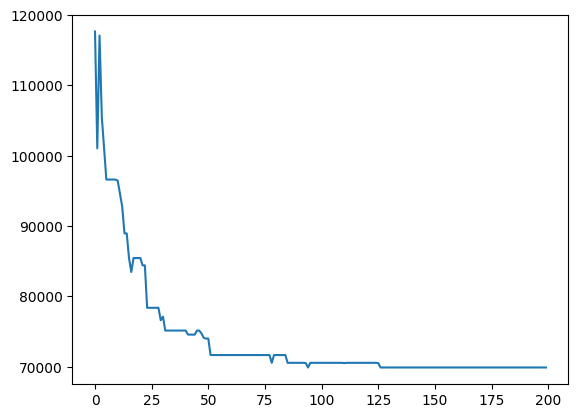

In [66]:
sns.lineplot(x=range(len(best_history)), y=best_history);